# Ex4.5 Cluster Sensitivity at 5% Noise

This notebook studies the DBSCAN clustering parameters $c_\epsilon$ and `min_samples` in Algorithm 3.


In [1]:
from importlib import reload
import torch
import numpy as np
import time
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import sys
sys.path.append(r"../main_code/2d")
import generate_data, mesh, adaptive_int, visual, matrix_assemble, inverse_solver, mea_2d, net_2d, source_eval, error_general_2d, main, bound_detect
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    r_y = np.linalg.norm(x - center, axis=-1)
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r):
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4
nx,ny=3,3
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5

num_batches_gauss=1
b_n=10
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n)
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=inverse_solver.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b)
initial_cells=copy.deepcopy(cells)
R_m=20


In [3]:
M=1600
af="Tanh"
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
loaded_model = torch.load("./Noise/noise=5%/models0_33_1600_7056_0.0009999999999999998.pth", map_location="cpu")[0][0]
models[0][0].load_state_dict(loaded_model.state_dict())
models = models[0][0].double().to(device)
with open("./Noise/noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store_last = pickle.load(f)
g_S=np.load("./Noise/noise=5%/g_S.npy")
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")

x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)


In [4]:

reload(bound_detect)

para_abs=3.0
para_grad=3.0
c_eps_center = 5.0
mini_samples_center = 20
perturbation_factor = np.array([0.8, 1.0, 1.2])

c_eps_values = np.round(c_eps_center * perturbation_factor, 2)
mini_samples_values = np.array(np.round(mini_samples_center * perturbation_factor), dtype=int)

cluster_results={}
cluster_count={}
shape_summary={}
plot_paths={}

output_dir = './Noise/noise=5%/cluster_parameter_sensitivity'
os.makedirs(output_dir, exist_ok=True)

for i, c_eps in enumerate(c_eps_values):
    for j, mini_samples in enumerate(mini_samples_values):
        filename = f'cluster_eps_{c_eps:.2f}_min_{int(mini_samples)}.png'
        full_path = os.path.join(output_dir, filename)

        fig_tmp, ax_tmp = plt.subplots(figsize=(4,4))
        detected = bound_detect.detect_shape(
            g_S, X.T, Y.T,
            tau_x_min, tau_x_max, tau_y_min, tau_y_max,
            para_abs, para_grad, float(c_eps), int(mini_samples),
            S_num_store[-1],
            ax=ax_tmp,
            fig=fig_tmp,
            output_directory=output_dir,
            output_filename=filename,
            show_colorbar=False,
            eps_mode='grid_scaled',
            min_cluster_size=200,
            min_relative_abs_s=0.2,
            min_relative_grad=0.25,
            keep_top_k=None,
        )
        plt.close(fig_tmp)

        cluster_results[(i,j)] = detected
        cluster_count[(i,j)] = len(detected)
        shape_summary[(i,j)] = '+'.join(sorted(item['shape'] for item in detected))
        plot_paths[(i,j)] = full_path
        print(
            f'(i={i}, j={j}) c_eps={c_eps:.2f}, mini_samples={int(mini_samples)}, '
            f'clusters={cluster_count[(i,j)]}, shapes={shape_summary[(i,j)]}'
        )


DBSCAN eps = 0.013333 (4.000000 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.92
  Res_Rect=0.032863 vs Res_Ellip=0.122733
  center=(0.3894, 0.4998)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.00
  Res_Rect=0.093626 vs Res_Ellip=0.012096
  center=(0.7098, 0.4996)
  -> Decision: Ellipsoid (Sigmoid)
(i=0, j=0) c_eps=4.00, mini_samples=16, clusters=2, shapes=Ellipsoid+Rectangle
DBSCAN eps = 0.013333 (4.000000 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.92
  Res_Rect=0.032863 vs Res_Ellip=0.122733
  center=(0.3894, 0.4998)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.00
  Res_Rect=0.093626 vs Res_Ellip=0.012096
  center=(0.7098, 0.4996)
  -> Decision: Ellipsoid (Sigmoid)
(i=0, j=1) c_eps=4.00, mini_samples=20, clusters=2, shapes=Ellipsoid+Rectangle
DBSCAN eps = 0.013333 (4.000000 * h, h = 0.0

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


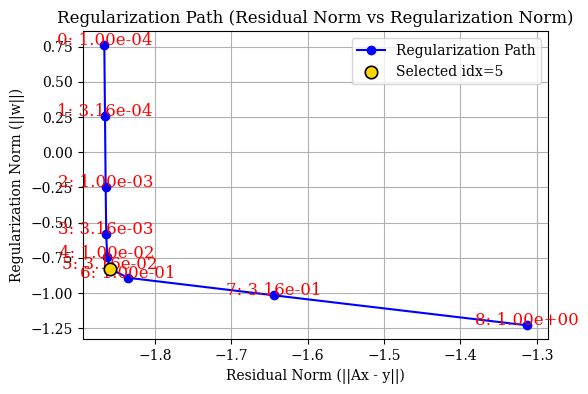

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.292162e-01
  idx=5, lambda=3.162278e-02, curvature=4.354438e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=9.683398e-01
(i=0, j=0) candidate idx: [4 5 6]
(i=0, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.5192731379673055 S_L_2= 0.06950419143592389 S_l_2= 0.15388321785006479
(i=0, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.5192731379673055, S_l_2=0.15388321785006479
S_l_inf= 1.5451632028397457 S_L_2= 0.07143240342976644 S_l_2= 0.15815230522709192
(i=0, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5451632028397457, S_l_2=0.15815230522709192
S_l_inf= 1.5439263802668668 S_L_2= 0.07432907144639196 S_l_2= 0.16456556730859728
(i=0, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5439263802668668, S_l_2=0.16456556730859728
(i=0, j=0) picked idx: 4
(i=0, j=0) picked lambda: 0.0001


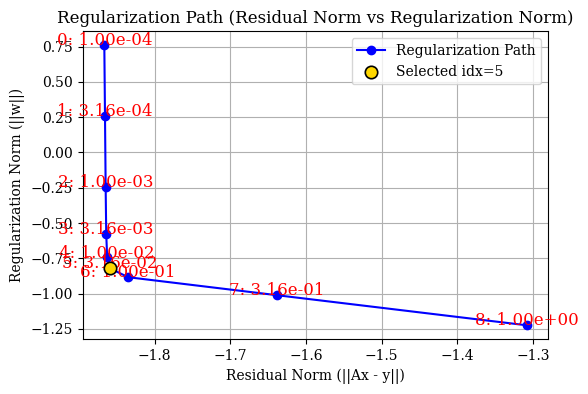

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.461218e-01
  idx=5, lambda=3.162278e-02, curvature=4.667070e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.959228e-01
(i=0, j=1) candidate idx: [4 5 6]
(i=0, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.6693003068562464 S_L_2= 0.06932170686595318 S_l_2= 0.1534791945493842
(i=0, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.6693003068562464, S_l_2=0.1534791945493842
S_l_inf= 1.6819716220433112 S_L_2= 0.07096934549426462 S_l_2= 0.15712708870857853
(i=0, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6819716220433112, S_l_2=0.15712708870857853
S_l_inf= 1.6778953340153275 S_L_2= 0.07376896076334473 S_l_2= 0.1633254746972191
(i=0, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6778953340153275, S_l_2=0.1633254746972191
(i=0, j=1) picked idx: 4
(i=0, j=1) picked lambda: 0.0001


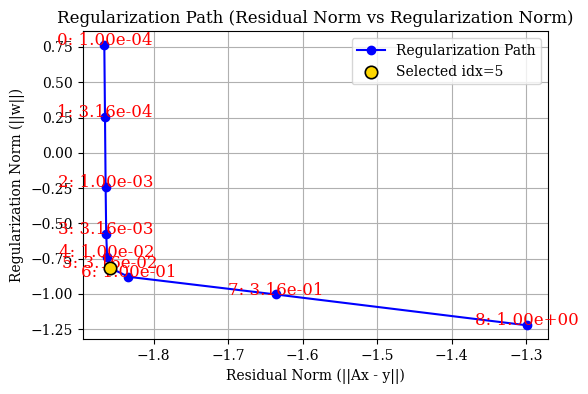

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.590291e-01
  idx=5, lambda=3.162278e-02, curvature=4.641764e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.834748e-01
(i=0, j=2) candidate idx: [4 5 6]
(i=0, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.468779446445522 S_L_2= 0.069148357799387 S_l_2= 0.15309539737653166
(i=0, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.468779446445522, S_l_2=0.15309539737653166
S_l_inf= 1.4890548843697031 S_L_2= 0.07108484367907837 S_l_2= 0.15738280324849035
(i=0, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.4890548843697031, S_l_2=0.15738280324849035
S_l_inf= 1.5093714390244501 S_L_2= 0.07416507075287238 S_l_2= 0.1642024675598332
(i=0, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5093714390244501, S_l_2=0.1642024675598332
(i=0, j=2) picked idx: 4
(i=0, j=2) picked lambda: 0.0001


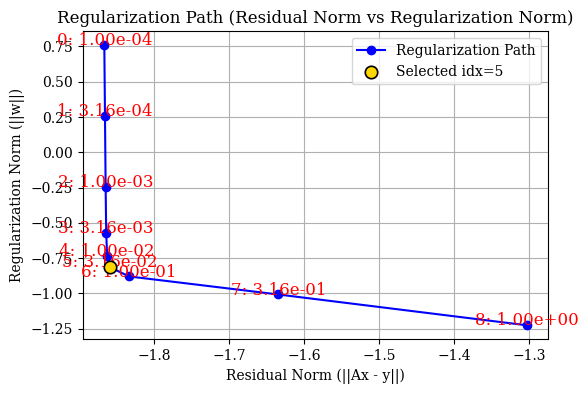

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.582914e-01
  idx=5, lambda=3.162278e-02, curvature=4.429321e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.687099e-01
(i=1, j=0) candidate idx: [4 5 6]
(i=1, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.4817193219757439 S_L_2= 0.06998608961934165 S_l_2= 0.1549501469317273
(i=1, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.4817193219757439, S_l_2=0.1549501469317273
S_l_inf= 1.5262901586444018 S_L_2= 0.07183223236512212 S_l_2= 0.15903753188595926
(i=1, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5262901586444018, S_l_2=0.15903753188595926
S_l_inf= 1.5574449705051023 S_L_2= 0.07473590865790035 S_l_2= 0.16546631038544862
(i=1, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5574449705051023, S_l_2=0.16546631038544862
(i=1, j=0) picked idx: 4
(i=1, j=0) picked lambda: 0.0001


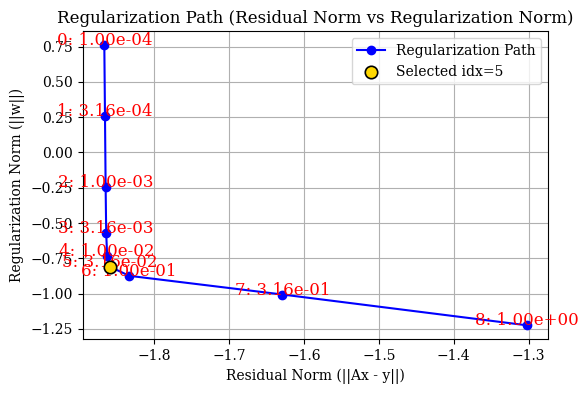

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.696598e-01
  idx=5, lambda=3.162278e-02, curvature=4.720170e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=7.928521e-01
(i=1, j=1) candidate idx: [4 5 6]
(i=1, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.5561160651428219 S_L_2= 0.06815251055622151 S_l_2= 0.15089057814046158
(i=1, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.5561160651428219, S_l_2=0.15089057814046158
S_l_inf= 1.5922514208003655 S_L_2= 0.0699350721083352 S_l_2= 0.15483719347383965
(i=1, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5922514208003655, S_l_2=0.15483719347383965
S_l_inf= 1.6076671800663922 S_L_2= 0.07294643922590144 S_l_2= 0.1615044009127777
(i=1, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6076671800663922, S_l_2=0.1615044009127777
(i=1, j=1) picked idx: 4
(i=1, j=1) picked lambda: 0.0001


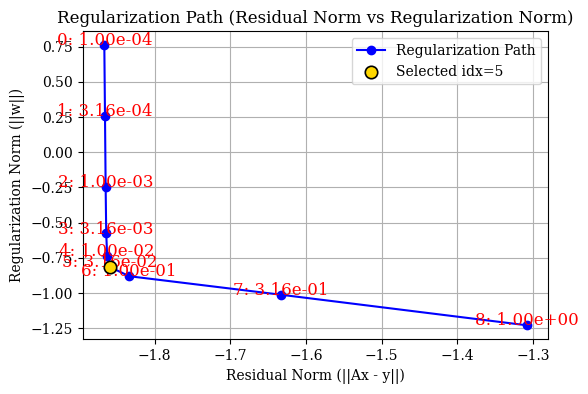

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.618633e-01
  idx=5, lambda=3.162278e-02, curvature=4.545111e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.305651e-01
(i=1, j=2) candidate idx: [4 5 6]
(i=1, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.6317927525227796 S_L_2= 0.06873560673386102 S_l_2= 0.1521815609470735
(i=1, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.6317927525227796, S_l_2=0.1521815609470735
S_l_inf= 1.629080481101224 S_L_2= 0.07080102660328123 S_l_2= 0.15675442841235226
(i=1, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.629080481101224, S_l_2=0.15675442841235226
S_l_inf= 1.6329226317728158 S_L_2= 0.0739042527259683 S_l_2= 0.16362501292833367
(i=1, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6329226317728158, S_l_2=0.16362501292833367
(i=1, j=2) picked idx: 4
(i=1, j=2) picked lambda: 0.0001


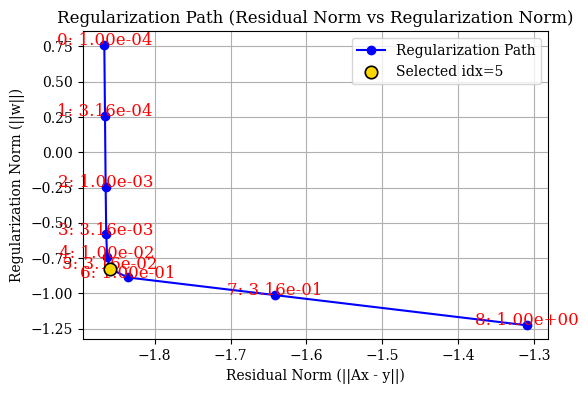

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.381157e-01
  idx=5, lambda=3.162278e-02, curvature=4.583226e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=9.293819e-01
(i=2, j=0) candidate idx: [4 5 6]
(i=2, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.663582518580213 S_L_2= 0.06934652636763008 S_l_2= 0.15353414526105455
(i=2, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.663582518580213, S_l_2=0.15353414526105455
S_l_inf= 1.6693696087703975 S_L_2= 0.07117412195619341 S_l_2= 0.1575804665589
(i=2, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6693696087703975, S_l_2=0.1575804665589
S_l_inf= 1.6553483889143086 S_L_2= 0.07389446567872542 S_l_2= 0.16360334427365442
(i=2, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6553483889143086, S_l_2=0.16360334427365442
(i=2, j=0) picked idx: 4
(i=2, j=0) picked lambda: 0.0001


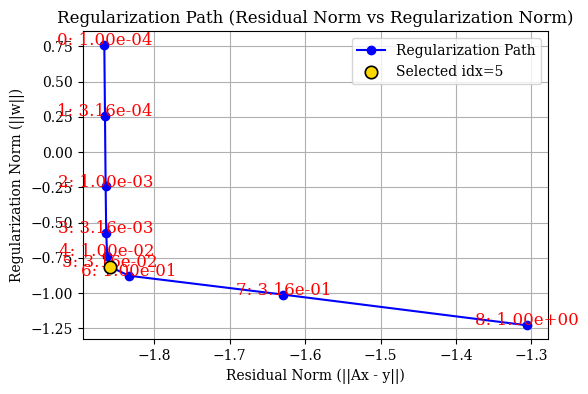

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.600421e-01
  idx=5, lambda=3.162278e-02, curvature=4.761730e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=7.852260e-01
(i=2, j=1) candidate idx: [4 5 6]
(i=2, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.698857515018882 S_L_2= 0.07004692899083334 S_l_2= 0.15508484612128262
(i=2, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.698857515018882, S_l_2=0.15508484612128262
S_l_inf= 1.7233887268473054 S_L_2= 0.07161320587991171 S_l_2= 0.15855260429177756
(i=2, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.7233887268473054, S_l_2=0.15855260429177756
S_l_inf= 1.7156710878797454 S_L_2= 0.07419827184157471 S_l_2= 0.16427597521829362
(i=2, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.7156710878797454, S_l_2=0.16427597521829362
(i=2, j=1) picked idx: 4
(i=2, j=1) picked lambda: 0.0001


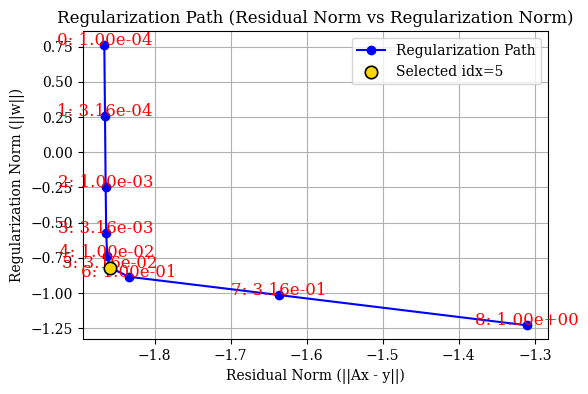

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.458561e-01
  idx=5, lambda=3.162278e-02, curvature=4.467076e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.769857e-01
(i=2, j=2) candidate idx: [4 5 6]
(i=2, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.5616232058881898 S_L_2= 0.06914961043721528 S_l_2= 0.15309817073358875
(i=2, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.5616232058881898, S_l_2=0.15309817073358875
S_l_inf= 1.5591188165068515 S_L_2= 0.07068400266071341 S_l_2= 0.15649533582418168
(i=2, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5591188165068515, S_l_2=0.15649533582418168
S_l_inf= 1.5542707793602135 S_L_2= 0.07335870213797605 S_l_2= 0.1624171565639065
(i=2, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5542707793602135, S_l_2=0.1624171565639065
(i=2, j=2) picked idx: 4
(i=2, j=2) picked lambda: 0.0001


In [5]:
Qx,Qy=150,150
M_ellip=800
M_rec=800
lamb_regu=np.logspace(-4,0,9,endpoint=True)
reload(inverse_solver)
reload(error_general_2d)
reload(net_2d)
reload(matrix_assemble)

S_l2={}
lambda_candidates={}
window_results_all={}
selected_idx={}
selected_lambda={}
selected_w={}

for i in range(len(c_eps_values)):
    for j in range(len(mini_samples_values)):
        current_results = cluster_results[(i,j)]
        c_eps = c_eps_values[i]
        mini_samples = mini_samples_values[j]

        rect_entry = next((item for item in current_results if item.get('shape') == 'Rectangle'), None)
        ellip_entry = next((item for item in current_results if item.get('shape') == 'Ellipsoid'), None)

        if rect_entry is None or ellip_entry is None:
            print(
                f'(i={i}, j={j}) c_eps={c_eps:.2f}, mini_samples={int(mini_samples)} '
                'missing Rectangle/Ellipsoid detection; skip this pair.'
            )
            S_l2[(i,j)] = np.nan
            lambda_candidates[(i,j)] = []
            window_results_all[(i,j)] = []
            selected_idx[(i,j)] = None
            selected_lambda[(i,j)] = np.nan
            selected_w[(i,j)] = None
            continue

        center1 = np.asarray(rect_entry['params']['center'])
        width = rect_entry['params']['W']
        height = rect_entry['params']['H']
        center2 = np.asarray(ellip_entry['params']['center'])
        a_ellip = float(ellip_entry['params'].get('a', ellip_entry['params'].get('radius')))
        b_ellip = float(ellip_entry['params'].get('b', ellip_entry['params'].get('radius')))

        theta_min, theta_max = -1e-12, 1e-12
        K_old_min = 1000
        K_old_max = 20000
        # Use the paper's 2D nondimensional K mapping:
        #   K_ellip = (a*b) * K_old, with semi-axes a and b.
        #   K_rec = sqrt((width/2)*(height/2)) * K_old = 0.5*sqrt(width*height) * K_old.
        ellip_char = a_ellip * b_ellip
        K_ellip_min = ellip_char * K_old_min
        K_ellip_max = ellip_char * K_old_max
        rect_char = 0.5 * np.sqrt(width * height)
        K_rec_min = rect_char * K_old_min
        K_rec_max = rect_char * K_old_max
        min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
        min_ellip1,max_ellip1=min(center2[0]*(1-0.05), center2[0]*(1+0.05)),max(center2[0]*(1-0.05), center2[0]*(1+0.05))
        min_ellip2,max_ellip2=min(center2[1]*(1-0.05), center2[1]*(1+0.05)),max(center2[1]*(1-0.05), center2[1]*(1+0.05))
        axis_a_min,axis_a_max=a_ellip*(1-0.1),a_ellip*(1+0.05)
        axis_b_min,axis_b_max=b_ellip*(1-0.1),b_ellip*(1+0.05)
        width_min,width_max=width*(1-0.1),width*(1+0.05)
        height_min,height_max=height*(1-0.1),height*(1+0.05)

        models0=models
        models1=net_2d.pre_define(Nx,Ny,M_ellip,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,theta_min,theta_max,min_ellip1,max_ellip1,min_ellip2,max_ellip2,axis_a_min,axis_a_max,axis_b_min,axis_b_max,[],[],[],[],K_ellip_min, K_ellip_max, 'ellipsoid',device)
        models2=net_2d.pre_define(Nx,Ny,M_rec,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_rec_min, K_rec_max, 'rec',device)

        sum_mat,all_g_p1,all_g_n,cells_copy1 = matrix_assemble.mat_assemble2(
            cells_store_last,models0,models1,models2,'mix','ellipsoid','rec',kk,0,points_b,device,cupy_device
        )
        res,reg_norm,w_store = inverse_solver.L_curve(sum_mat,F_05,[],[],[],lamb_regu,'linear',device,cupy_device)
        window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
            lamb_regu, res, reg_norm, radius=1, w_store=w_store
        )

        lambda_candidates[(i,j)] = [float(val**2) for val in window_lambda]
        print(f'(i={i}, j={j}) candidate idx: {window_idx}')
        print(f'(i={i}, j={j}) candidate lambda: {lambda_candidates[(i,j)]}')

        window_results = []
        for local_i, cand_idx in enumerate(window_idx):
            cand_lamb = window_lambda[local_i]**2
            cand_w = window_w[:, local_i]
            result_tuple = error_general_2d.test(
                models0,models1,models2,[],Qx,Qy,cand_w,'mix','ellipsoid','rec',
                False,False,tau_x_min,tau_x_max,tau_y_min,tau_y_max,
                x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,0,device
            )
            window_results.append({
                'idx': int(cand_idx),
                'lambda': float(cand_lamb),
                'w': cand_w,
                'result': result_tuple,
            })
            print(
                f'(i={i}, j={j}) candidate idx={int(cand_idx)}, lamb={cand_lamb}, '
                f'S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}'
            )

        window_results_all[(i,j)] = window_results
        pick = 0
        picked = window_results[pick]
        selected_idx[(i,j)] = picked['idx']
        selected_lambda[(i,j)] = picked['lambda']
        selected_w[(i,j)] = picked['w']
        S_l2[(i,j)] = picked['result'][3]
        print(f'(i={i}, j={j}) picked idx: {selected_idx[(i,j)]}')
        print(f'(i={i}, j={j}) picked lambda: {selected_lambda[(i,j)]}')

        del models1, models2, sum_mat, all_g_p1, all_g_n, cells_copy1, res, reg_norm, w_store, window_results
        if device.type == 'cuda':
            torch.cuda.empty_cache()


In [6]:

from collections import Counter

summary_records = []
for i, c_eps in enumerate(c_eps_values):
    for j, mini_samples in enumerate(mini_samples_values):
        key = (i, j)
        detected_items = cluster_results[key]
        profile_summary = '+'.join(
            sorted(f"{item.get('shape', '')}({item.get('profile', '')})" for item in detected_items)
        )
        record = {
            'i': int(i),
            'j': int(j),
            'c_eps': float(c_eps),
            'mini_samples': int(mini_samples),
            'cluster_count': int(cluster_count.get(key, 0)),
            'shape_summary': shape_summary.get(key, ''),
            'profile_summary': profile_summary,
            'selected_idx': selected_idx.get(key, None),
            'selected_lambda': float(selected_lambda.get(key, np.nan)),
            'S_l2': float(S_l2.get(key, np.nan)),
            'is_valid': bool(np.isfinite(S_l2.get(key, np.nan))),
        }
        summary_records.append(record)

cluster_distribution = Counter(record['cluster_count'] for record in summary_records)
shape_distribution = Counter(record['shape_summary'] for record in summary_records)
profile_distribution = Counter(record['profile_summary'] for record in summary_records)
shape_labels = sorted(shape_distribution.keys())
profile_labels = sorted(profile_distribution.keys())

print('Per-grid clustering-parameter / shape / profile summary:')
for record in summary_records:
    print(
        f"(i={record['i']}, j={record['j']}) "
        f"c_eps={record['c_eps']:.2f}, "
        f"mini_samples={record['mini_samples']}, "
        f"-> shapes={record['shape_summary']}, "
        f"profiles={record['profile_summary']}, "
        f"clusters={record['cluster_count']}, "
        f"valid={record['is_valid']}, "
        f"lambda={record['selected_lambda']:.6e}, "
        f"S_l2={record['S_l2']:.6e}"
    )

print('\nCluster-count distribution:')
for key in sorted(cluster_distribution):
    print(f"clusters={key}: {cluster_distribution[key]} runs")

print('\nShape-summary distribution:')
for key in shape_labels:
    print(f"{key}: {shape_distribution[key]} runs")

print('\nProfile-summary distribution:')
for key in profile_labels:
    print(f"{key}: {profile_distribution[key]} runs")


Per-grid clustering-parameter / shape / profile summary:
(i=0, j=0) c_eps=4.00, mini_samples=16, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.538832e-01
(i=0, j=1) c_eps=4.00, mini_samples=20, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.534792e-01
(i=0, j=2) c_eps=4.00, mini_samples=24, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.530954e-01
(i=1, j=0) c_eps=5.00, mini_samples=16, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.549501e-01
(i=1, j=1) c_eps=5.00, mini_samples=20, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.508906e-01
(i=1, j=2) c_eps=5.00, mini_sampl


## Cluster-Sensitivity Gallery

This section assembles the 9 detection figures from the 3×3 perturbation grid centered at $(c_{\epsilon},\mathrm{min\_samples})=(5,20)$.


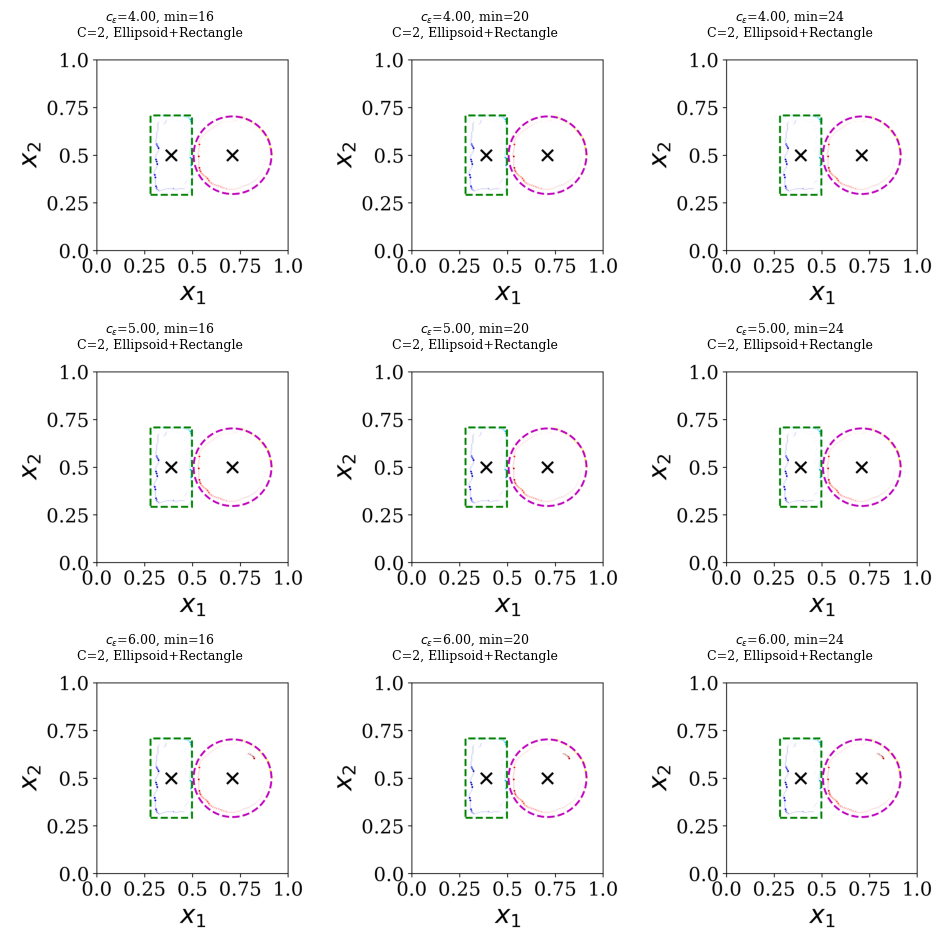

In [7]:

import matplotlib.image as mpimg

fig_gallery, axes_gallery = plt.subplots(
    len(c_eps_values),
    len(mini_samples_values),
    figsize=(3.2 * len(mini_samples_values), 3.2 * len(c_eps_values))
)

for i, c_eps in enumerate(c_eps_values):
    for j, mini_samples in enumerate(mini_samples_values):
        ax = axes_gallery[i, j]
        img = mpimg.imread(plot_paths[(i, j)])
        ax.imshow(img)
        ax.set_title(
            f'$c_\epsilon$={c_eps:.2f}, min={int(mini_samples)}\n'
            f'C={cluster_count[(i,j)]}, {shape_summary[(i,j)]}',
            fontsize=9,
        )
        ax.axis('off')

plt.tight_layout()
plt.savefig('./Noise/noise=5%/cluster_parameter_sensitivity/cluster_parameter_sensitivity_overview.pdf', dpi=300, bbox_inches='tight')
plt.show()


,i,j,c_eps,mini_samples,shape_summary,profile_summary,cluster_count,selected_idx,selected_lambda,S_l2,is_valid
0,0,0,4.0,16,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.539e-01,True
1,0,1,4.0,20,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.535e-01,True
2,0,2,4.0,24,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.531e-01,True
3,1,0,5.0,16,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.550e-01,True
4,1,1,5.0,20,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.509e-01,True
5,1,2,5.0,24,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.522e-01,True
6,2,0,6.0,16,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.535e-01,True
7,2,1,6.0,20,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.551e-01,True
8,2,2,6.0,24,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.531e-01,True


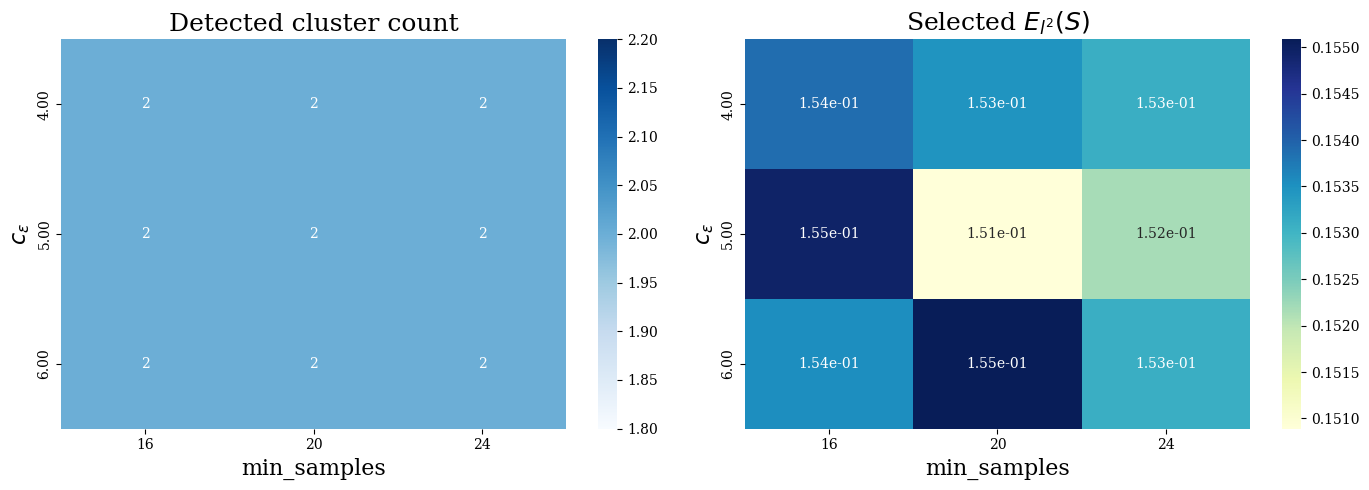

In [8]:

import pandas as pd
from IPython.display import display

summary_df = pd.DataFrame(summary_records)
summary_df = summary_df[[
    'i',
    'j',
    'c_eps',
    'mini_samples',
    'shape_summary',
    'profile_summary',
    'cluster_count',
    'selected_idx',
    'selected_lambda',
    'S_l2',
    'is_valid',
]].copy()
summary_df = summary_df.sort_values(['i', 'j']).reset_index(drop=True)
summary_df['c_eps'] = summary_df['c_eps'].round(2)
summary_df['selected_lambda'] = summary_df['selected_lambda'].map(lambda v: f"{v:.3e}" if np.isfinite(v) else 'nan')
summary_df['S_l2'] = summary_df['S_l2'].map(lambda v: f"{v:.3e}" if np.isfinite(v) else 'nan')

display(summary_df)
summary_df.to_csv('./Noise/noise=5%/cluster_parameter_sensitivity_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_data = np.array([
    [cluster_count[(i, j)] for j in range(len(mini_samples_values))]
    for i in range(len(c_eps_values))
])
err_data = np.array([
    [S_l2[(i, j)] for j in range(len(mini_samples_values))]
    for i in range(len(c_eps_values))
])

sns.heatmap(
    cluster_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=mini_samples_values,
    yticklabels=[f"{val:.2f}" for val in c_eps_values],
    ax=axes[0],
)
axes[0].set_xlabel('min_samples', fontsize=16)
axes[0].set_ylabel(r'$c_{\epsilon}$', fontsize=16)
axes[0].set_title('Detected cluster count', fontsize=18)

sns.heatmap(
    err_data,
    annot=True,
    fmt='.2e',
    cmap='YlGnBu',
    xticklabels=mini_samples_values,
    yticklabels=[f"{val:.2f}" for val in c_eps_values],
    ax=axes[1],
)
axes[1].set_xlabel('min_samples', fontsize=16)
axes[1].set_ylabel(r'$c_{\epsilon}$', fontsize=16)
axes[1].set_title(r'Selected $E_{l^2}(S)$', fontsize=18)

plt.tight_layout()
plt.savefig('./Noise/noise=5%/cluster_parameter_sensitivity_analysis.pdf', dpi=300)
plt.show()


In [9]:

with open('./Noise/noise=5%/cluster_parameter_sensitivity_results.pkl', 'wb') as f:
    pickle.dump(
        {
            'c_eps_center': c_eps_center,
            'mini_samples_center': mini_samples_center,
            'perturbation_factor': perturbation_factor,
            'c_eps_values': c_eps_values,
            'mini_samples_values': mini_samples_values,
            'cluster_count': cluster_count,
            'shape_summary': shape_summary,
            'S_l2': S_l2,
            'selected_idx': selected_idx,
            'selected_lambda': selected_lambda,
            'lambda_candidates': lambda_candidates,
            'plot_paths': plot_paths,
            'summary_records': summary_records,
            'cluster_distribution': dict(cluster_distribution),
            'shape_distribution': dict(shape_distribution),
            'profile_distribution': dict(profile_distribution),
        },
        f,
    )
